In [4]:
!pip install -q medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 2.3 MB/s eta 0:00:00


# Notebook: Redes Neuronales Convolucionales (CNN) para Imágenes Médicas

Este notebook es una guía completa y práctica para aprender **CNN (Convolutional Neural Networks)** aplicadas a **imágenes médicas**.

Trabajaremos con un conjunto de datos **libre y de fácil descarga** desde el paquete `medmnist`: **PneumoniaMNIST**, un dataset de radiografías de tórax en formato 2D, con etiquetas binarias (neumonía vs. no neumonía).

Al final tendrás:
- Un modelo CNN entrenado desde cero.
- Un ejemplo de **transfer learning** usando un modelo preentrenado.
- Evaluación con métricas útiles en contexto médico.
- Un vistazo a interpretabilidad con **Grad-CAM**.

⚠️ Nota importante (contexto médico): este material es educativo. Un modelo entrenado aquí **no** debe usarse para diagnóstico clínico sin validación rigurosa, controles de sesgo, y aprobación regulatoria.


## 1. ¿Qué es una CNN y por qué se usa en imágenes?

Una **CNN** es un tipo de red neuronal diseñada para trabajar con datos que tienen estructura espacial, como imágenes.

En una imagen, los píxeles cercanos suelen estar relacionados (bordes, texturas, formas). Las CNN explotan esta propiedad mediante **convoluciones**, que son filtros aprendibles que se deslizan por la imagen para detectar patrones.

### 1.1. Componentes clave

**(a) Convolución (Conv2D)**
- Aplica filtros (kernels) para obtener mapas de características.
- Aprende detectores de bordes, texturas y estructuras más complejas en capas profundas.

**(b) Activación (ReLU)**
- Introduce no linealidad.
- ReLU(x) = max(0, x) suele funcionar muy bien.

**(c) Pooling (MaxPool)**
- Reduce resolución espacial, mantiene información importante.
- Ayuda a generalización y reduce costo computacional.

**(d) Capas fully-connected (densas)**
- Integran la información para clasificación/regresión.

### 1.2. ¿Por qué CNN para imágenes médicas?
- Detectan patrones sutiles (opacidades, consolidaciones, cambios de textura).
- Pueden aprender representaciones jerárquicas sin ingeniería manual de características.
- Con **transfer learning**, aprovechan conocimiento de grandes datasets para mejorar rendimiento con menos datos.


## 2. Preparación del entorno

Usaremos **PyTorch** para construir y entrenar modelos. También usaremos `medmnist` para descargar el dataset.

Si estás en un entorno local, ejecuta la instalación. En entornos tipo Colab, puede que ya esté instalado.


In [ ]:
import sys
import subprocess

packages = [
    "torch",
    "torchvision",
    "medmnist",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "tqdm"
]

for p in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])


## 3. Cargar el dataset médico (PneumoniaMNIST)

`medmnist` ofrece datasets médicos estandarizados y fáciles de usar.

Características del dataset en este ejercicio:
- Entrada: imágenes 2D (radiografías de tórax) de tamaño pequeño.
- Etiquetas: clasificación binaria.
- Particiones: train/val/test ya vienen definidas.


In [ ]:
import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt
from tqdm import tqdm

import medmnist
from medmnist import INFO

data_flag = "pneumoniamnist"
info = INFO[data_flag]

DataClass = getattr(medmnist, info["python_class"])

info


{'python_class': 'PneumoniaMNIST',
 'description': 'The PneumoniaMNIST is based on a prior dataset of 5,856 pediatric chest X-Ray images. The task is binary-class classification of pneumonia against normal. We split the source training set with a ratio of 9:1 into training and validation set and use its source validation set as the test set. The source images are gray-scale, and their sizes are (384−2,916)×(127−2,713). We center-crop the images and resize them into 1×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/pneumoniamnist.npz?download=1',
 'MD5': '28209eda62fecd6e6a2d98b1501bb15f',
 'url_64': 'https://zenodo.org/records/10519652/files/pneumoniamnist_64.npz?download=1',
 'MD5_64': '8f4eceb4ccffa70c672198ea285246c6',
 'url_128': 'https://zenodo.org/records/10519652/files/pneumoniamnist_128.npz?download=1',
 'MD5_128': '05b46931834c231683c68f40c47b2971',
 'url_224': 'https://zenodo.org/records/10519652/files/pneumoniamnist_224.npz?download=1',
 'MD5_224': 'd6a3c71de1b94

In [ ]:
transform_basic = T.Compose([
    T.ToTensor()
])

train_dataset = DataClass(split="train", transform=transform_basic, download=True)
val_dataset = DataClass(split="val", transform=transform_basic, download=True)
test_dataset = DataClass(split="test", transform=transform_basic, download=True)

len(train_dataset), len(val_dataset), len(test_dataset)


100%|██████████| 4.17M/4.17M [00:01<00:00, 3.28MB/s]


(4708, 524, 624)

### 3.1. Visualizar ejemplos

Una buena práctica inicial es ver ejemplos del dataset para entender su formato, niveles de ruido, variabilidad, etc.


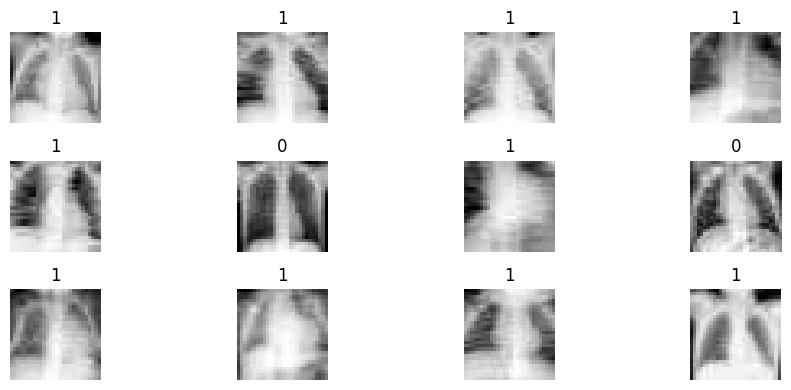

In [ ]:
def show_batch(dataset, n=12):
    plt.figure(figsize=(10, 4))
    for i in range(n):
        x, y = dataset[i]
        plt.subplot(3, 4, i+1)
        img = x.squeeze(0)
        plt.imshow(img, cmap="gray")
        plt.title(int(y.item()))
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_dataset, n=12)


## 4. Preparar DataLoaders y device

Los **DataLoaders** manejan el batching y el shuffle. El **device** nos permite usar GPU si existe.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [ ]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape


(torch.Size([128, 1, 28, 28]), torch.Size([128, 1]))

## 5. Modelo 1: CNN entrenada desde cero

Construiremos una CNN básica y razonable:
- Bloques conv + ReLU + pooling.
- Al final, un clasificador.

Esta arquitectura no es la única posible: lo valioso es comprender el patrón de diseño.


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

num_classes = len(info["label"])

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_scratch = SimpleCNN(num_classes=num_classes).to(device)
model_scratch


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=2, bias=True)
  )
)

### 5.1. Funciones de entrenamiento y evaluación

En clasificación médica es útil mirar:
- **Accuracy** (porcentaje correcto)
- **ROC-AUC** (capacidad de separar clases)
- **Matriz de confusión**
- **Precision/Recall/F1** (útiles cuando hay desbalance)

Aquí implementaremos un loop de entrenamiento estándar.


In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

def logits_to_probs(logits):
    if logits.shape[1] == 1:
        return torch.sigmoid(logits).squeeze(1)
    return torch.softmax(logits, dim=1)[:, 1]

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_labels = []
    all_probs = []
    all_preds = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        logits = model(x)
        probs = logits_to_probs(logits)
        preds = (probs >= 0.5).long()

        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)

    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    return acc, auc, y_true, y_pred, y_prob

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    losses = []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
    return float(np.mean(losses))


### 5.2. Entrenar el modelo desde cero

Entrenaremos unas pocas épocas para un ejemplo reproducible.
En práctica real, harías búsqueda de hiperparámetros, early stopping y validación más cuidadosa.


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_scratch.parameters(), lr=1e-3)

epochs = 8
history_scratch = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_scratch, train_loader, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(model_scratch, val_loader)

    history_scratch["train_loss"].append(train_loss)
    history_scratch["val_acc"].append(val_acc)
    history_scratch["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Epoch 01 | train_loss=0.5944 | val_acc=0.7424 | val_auc=0.5917
Epoch 02 | train_loss=0.5463 | val_acc=0.7271 | val_auc=0.7457
Epoch 03 | train_loss=0.4828 | val_acc=0.7519 | val_auc=0.8480
Epoch 04 | train_loss=0.4056 | val_acc=0.8588 | val_auc=0.9091
Epoch 05 | train_loss=0.3304 | val_acc=0.8263 | val_auc=0.9090
Epoch 06 | train_loss=0.2913 | val_acc=0.8492 | val_auc=0.9257
Epoch 07 | train_loss=0.2822 | val_acc=0.8798 | val_auc=0.9445
Epoch 08 | train_loss=0.2604 | val_acc=0.8874 | val_auc=0.9509


### 5.3. Curvas de entrenamiento

Visualizamos pérdida y métricas para detectar sobreajuste.


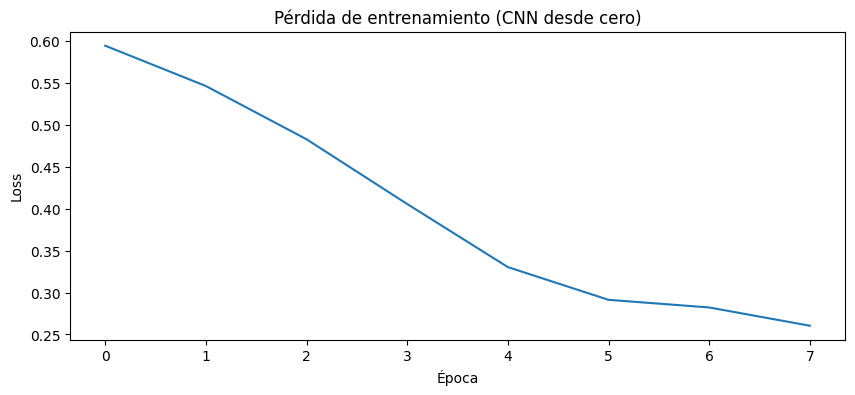

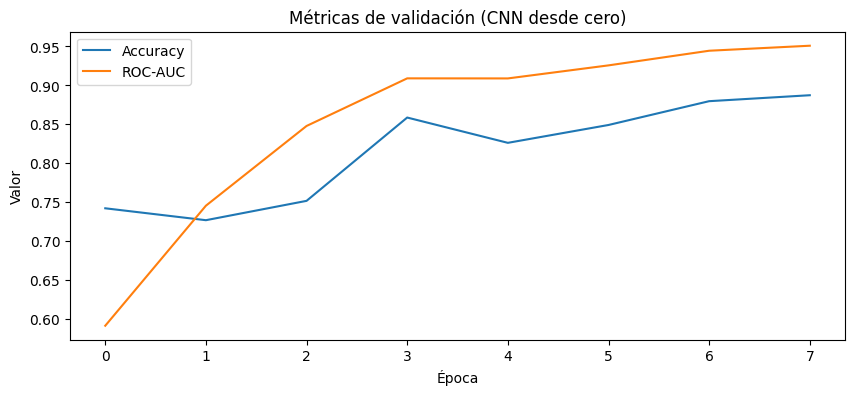

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(history_scratch["train_loss"])
plt.title("Pérdida de entrenamiento (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_scratch["val_acc"], label="Accuracy")
plt.plot(history_scratch["val_auc"], label="ROC-AUC")
plt.title("Métricas de validación (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.legend()
plt.show()


### 5.4. Evaluación final en test

La evaluación debe reportarse en un conjunto **no visto** (test) para estimar generalización.


In [ ]:
test_acc, test_auc, y_true, y_pred, y_prob = evaluate(model_scratch, test_loader)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test ROC-AUC:  {test_auc:.4f}")
print()
print(classification_report(y_true, y_pred, digits=4))
cm = confusion_matrix(y_true, y_pred)
cm


Test accuracy: 0.8798
Test ROC-AUC:  0.9375

              precision    recall  f1-score   support

           0     0.8383    0.8419    0.8401       234
           1     0.9049    0.9026    0.9037       390

    accuracy                         0.8798       624
   macro avg     0.8716    0.8722    0.8719       624
weighted avg     0.8799    0.8798    0.8799       624



array([[197,  37],
       [ 38, 352]])

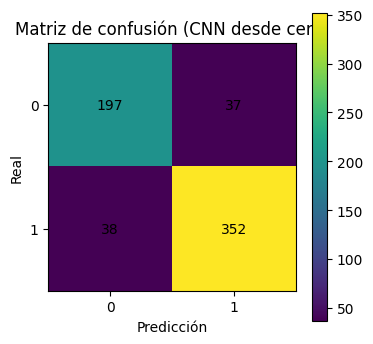

In [ ]:
plt.figure(figsize=(4, 4))
plt.imshow(cm)
plt.title("Matriz de confusión (CNN desde cero)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks([0, 1])
plt.yticks([0, 1])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.show()


## 6. Data Augmentation (aumento de datos)

En imágenes médicas, el aumento de datos ayuda a generalizar, pero debe aplicarse con cuidado:
- Rotaciones pequeñas y traslaciones suaves suelen ser aceptables.
- Inversiones horizontales/verticales podrían ser inválidas dependiendo del estudio.

Aquí usaremos aumentos moderados. Luego, entrenaremos un modelo con el mismo diseño para comparar.


In [ ]:
transform_aug = T.Compose([
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor()
])

train_dataset_aug = DataClass(split="train", transform=transform_aug, download=True)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)


In [ ]:
model_aug = SimpleCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_aug.parameters(), lr=1e-3)

epochs = 6
history_aug = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_aug, train_loader_aug, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(model_aug, val_loader)

    history_aug["train_loss"].append(train_loss)
    history_aug["val_acc"].append(val_acc)
    history_aug["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Epoch 01 | train_loss=0.5844 | val_acc=0.7424 | val_auc=0.5531
Epoch 02 | train_loss=0.5669 | val_acc=0.7424 | val_auc=0.6607
Epoch 03 | train_loss=0.5485 | val_acc=0.7424 | val_auc=0.7432
Epoch 04 | train_loss=0.4897 | val_acc=0.7405 | val_auc=0.8213
Epoch 05 | train_loss=0.4079 | val_acc=0.7996 | val_auc=0.8833
Epoch 06 | train_loss=0.3335 | val_acc=0.8550 | val_auc=0.9261


### 6.1. Comparación rápida


In [ ]:
test_acc_aug, test_auc_aug, _, _, _ = evaluate(model_aug, test_loader)
print(f"Sin augmentation  | test_acc={test_acc:.4f} | test_auc={test_auc:.4f}")
print(f"Con augmentation  | test_acc={test_acc_aug:.4f} | test_auc={test_auc_aug:.4f}")


Sin augmentation  | test_acc=0.8798 | test_auc=0.9375
Con augmentation  | test_acc=0.8093 | test_auc=0.9198


## 7. Transfer Learning en imágenes médicas

El **transfer learning** consiste en reutilizar un modelo entrenado en un dataset grande (por ejemplo, ImageNet) y adaptarlo a tu tarea.

Ventajas:
- Converge más rápido.
- Suele mejorar rendimiento con pocos datos.

Desafíos en imágenes médicas:
- Muchas imágenes médicas son en escala de grises.
- El dominio es distinto a fotos naturales.

Aun así, usar redes como ResNet puede ayudar. Aquí haremos:
1) Convertir la imagen a 3 canales.
2) Redimensionar a un tamaño típico de ResNet.
3) Entrenar un clasificador encima.


In [ ]:
import torchvision.models as models

transform_tl_train = T.Compose([
    T.Resize((224, 224)),
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1))
])

transform_tl_eval = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1))
])

train_dataset_tl = DataClass(split="train", transform=transform_tl_train, download=True)
val_dataset_tl = DataClass(split="val", transform=transform_tl_eval, download=True)
test_dataset_tl = DataClass(split="test", transform=transform_tl_eval, download=True)

train_loader_tl = DataLoader(train_dataset_tl, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader_tl = DataLoader(val_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader_tl = DataLoader(test_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader_tl))[0].shape


torch.Size([64, 3, 224, 224])

### 7.1. Construir el modelo preentrenado

Usaremos **ResNet18** preentrenada en ImageNet.

Estrategia:
- Congelar el backbone al inicio.
- Entrenar solo la última capa.
- Luego, opcionalmente, descongelar algunas capas para fine-tuning.


In [ ]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
in_features = resnet.fc.in_features
resnet.fc = nn.Linear(in_features, num_classes)
resnet = resnet.to(device)

for name, param in resnet.named_parameters():
    param.requires_grad = False

for param in resnet.fc.parameters():
    param.requires_grad = True

resnet


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 213MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)

epochs = 4
history_tl_stage1 = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(resnet, val_loader_tl)

    history_tl_stage1["train_loss"].append(train_loss)
    history_tl_stage1["val_acc"].append(val_acc)
    history_tl_stage1["val_auc"].append(val_auc)

    print(f"Stage1 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Stage1 Epoch 01 | train_loss=0.4749 | val_acc=0.7767 | val_auc=0.8335
Stage1 Epoch 02 | train_loss=0.3238 | val_acc=0.8511 | val_auc=0.9179
Stage1 Epoch 03 | train_loss=0.2828 | val_acc=0.8492 | val_auc=0.9358
Stage1 Epoch 04 | train_loss=0.2781 | val_acc=0.8664 | val_auc=0.9406


### 7.2. Fine-tuning (descongelar capas)

Ahora permitiremos que el modelo ajuste parte del backbone.
Una práctica común es descongelar las últimas capas del extractor de características.


In [ ]:
for name, param in resnet.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

trainable_params = [p for p in resnet.parameters() if p.requires_grad]
len(trainable_params)


17

In [ ]:
optimizer = torch.optim.Adam(trainable_params, lr=1e-4)

epochs = 4
history_tl_stage2 = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(resnet, val_loader_tl)

    history_tl_stage2["train_loss"].append(train_loss)
    history_tl_stage2["val_acc"].append(val_acc)
    history_tl_stage2["val_auc"].append(val_auc)

    print(f"Stage2 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Stage2 Epoch 01 | train_loss=0.1588 | val_acc=0.9351 | val_auc=0.9855
Stage2 Epoch 02 | train_loss=0.0967 | val_acc=0.9542 | val_auc=0.9885
Stage2 Epoch 03 | train_loss=0.0752 | val_acc=0.9599 | val_auc=0.9907
Stage2 Epoch 04 | train_loss=0.0632 | val_acc=0.9523 | val_auc=0.9918


### 7.3. Evaluación en test del modelo con transfer learning


In [ ]:
test_acc_tl, test_auc_tl, y_true_tl, y_pred_tl, y_prob_tl = evaluate(resnet, test_loader_tl)
print(f"Transfer learning | test_acc={test_acc_tl:.4f} | test_auc={test_auc_tl:.4f}")
print()
print(classification_report(y_true_tl, y_pred_tl, digits=4))
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
cm_tl


Transfer learning | test_acc=0.8702 | test_auc=0.9648

              precision    recall  f1-score   support

           0     0.9527    0.6880    0.7990       234
           1     0.8396    0.9795    0.9041       390

    accuracy                         0.8702       624
   macro avg     0.8961    0.8338    0.8516       624
weighted avg     0.8820    0.8702    0.8647       624



array([[161,  73],
       [  8, 382]])

### 7.4. Comparación global (resumen)


In [ ]:
print("Resumen de resultados en test")
print(f"CNN desde cero (sin aug)  | acc={test_acc:.4f} | auc={test_auc:.4f}")
print(f"CNN desde cero (con aug)  | acc={test_acc_aug:.4f} | auc={test_auc_aug:.4f}")
print(f"Transfer learning (ResNet) | acc={test_acc_tl:.4f} | auc={test_auc_tl:.4f}")


Resumen de resultados en test
CNN desde cero (sin aug)  | acc=0.8798 | auc=0.9375
CNN desde cero (con aug)  | acc=0.8093 | auc=0.9198
Transfer learning (ResNet) | acc=0.8702 | auc=0.9648


## 8. Interpretabilidad básica: Grad-CAM

En salud, entender por qué el modelo decide es importante.

**Grad-CAM** produce un mapa de calor sobre la imagen, indicando regiones que más influyeron en la predicción.

Aquí implementaremos una versión simplificada para ResNet18.


In [ ]:
import torch

def grad_cam(model, image_tensor, target_class=None):
    model.eval()
    image_tensor = image_tensor.to(device)

    activations = {}
    gradients = {}

    def forward_hook(module, inp, out):
        activations["value"] = out

    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    handle_fwd = model.layer4.register_forward_hook(forward_hook)
    handle_bwd = model.layer4.register_full_backward_hook(backward_hook)

    logits = model(image_tensor.unsqueeze(0))
    if target_class is None:
        target_class = int(torch.argmax(logits, dim=1).item())

    score = logits[0, target_class]
    model.zero_grad()
    score.backward()

    act = activations["value"][0]
    grad = gradients["value"][0]

    weights = torch.mean(grad, dim=(1, 2))
    cam = torch.sum(weights[:, None, None] * act, dim=0)

    cam = torch.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    handle_fwd.remove()
    handle_bwd.remove()

    return cam.detach().cpu().numpy(), target_class


sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


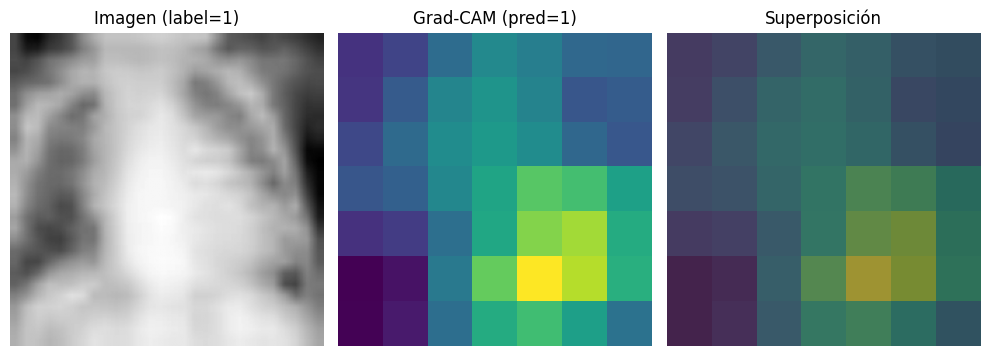

In [ ]:
idx = 0
x, y = test_dataset_tl[idx]
cam, pred_class = grad_cam(resnet, x)

img = x[0].numpy()
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title(f"Imagen (label={int(y.item())})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam)
plt.title(f"Grad-CAM (pred={pred_class})")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img, cmap="gray")
plt.imshow(cam, alpha=0.5)
plt.title("Superposición")
plt.axis("off")

plt.tight_layout()
plt.show()


## 9. Buenas prácticas (especialmente en salud)

1) **Separación estricta** de train/val/test para evitar data leakage.

2) Reportar métricas más allá de accuracy:
- **Recall (sensibilidad)**: qué tanto detectas positivos.
- **Especificidad**: qué tanto evitas falsos positivos.
- **ROC-AUC**: separación global.

3) Cuidado con sesgos:
- Diferencias por equipo, hospital, población.
- Etiquetas ruidosas.

4) Validación externa:
- Probar en datos de otra fuente es clave.

5) Interpretabilidad:
- Grad-CAM es útil, pero no prueba causalidad.

6) Reproducibilidad:
- Fijar seeds, registrar versiones, guardar modelos.


## 10. Guardar y cargar modelos

Guardar el modelo permite reutilizarlo y desplegarlo en aplicaciones.


In [ ]:
import os

os.makedirs("models", exist_ok=True)

torch.save(model_scratch.state_dict(), "models/cnn_scratch.pth")
torch.save(model_aug.state_dict(), "models/cnn_aug.pth")
torch.save(resnet.state_dict(), "models/resnet_transfer.pth")

["models/cnn_scratch.pth", "models/cnn_aug.pth", "models/resnet_transfer.pth"]


['models/cnn_scratch.pth', 'models/cnn_aug.pth', 'models/resnet_transfer.pth']

## 11. Ejercicios sugeridos

1) Cambia la arquitectura de la CNN: agrega BatchNorm, Dropout, o más filtros.

2) Experimenta con learning rate y scheduler.

3) Analiza el impacto de diferentes aumentos de datos.

4) Cambia el dataset dentro de `medmnist` (por ejemplo: `breastmnist`, `dermamnist`) y adapta el pipeline.

5) Implementa calibración de probabilidades y analiza curvas ROC.


# Ejercicio: Mejora de la Arquitectura y Optimización

En esta sección aplicamos:
- **Batch Normalization** después de cada convolución.
- **Dropout** en la capa densa.
- Un **Learning Rate Scheduler** para ajustar el ritmo de aprendizaje.

In [ ]:
class ImprovedCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_improved = ImprovedCNN(num_classes=num_classes).to(device)
model_improved

ImprovedCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(

In [ ]:
optimizer = torch.optim.Adam(model_improved.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)
criterion = nn.CrossEntropyLoss()

epochs = 10
history_improved = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_improved, train_loader, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(model_improved, val_loader)

    # Actualizar scheduler
    scheduler.step()

    history_improved["train_loss"].append(train_loss)
    history_improved["val_acc"].append(val_acc)
    history_improved["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | LR={scheduler.get_last_lr()[0]:.6f} | loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

Epoch 01 | LR=0.001000 | loss=0.3723 | val_acc=0.7424 | val_auc=0.8336
Epoch 02 | LR=0.001000 | loss=0.1820 | val_acc=0.9332 | val_auc=0.9847
Epoch 03 | LR=0.001000 | loss=0.1336 | val_acc=0.9218 | val_auc=0.9871
Epoch 04 | LR=0.001000 | loss=0.1328 | val_acc=0.9370 | val_auc=0.9892
Epoch 05 | LR=0.000100 | loss=0.1052 | val_acc=0.8263 | val_auc=0.9910
Epoch 06 | LR=0.000100 | loss=0.0935 | val_acc=0.9580 | val_auc=0.9946
Epoch 07 | LR=0.000100 | loss=0.0890 | val_acc=0.9599 | val_auc=0.9954
Epoch 08 | LR=0.000100 | loss=0.0851 | val_acc=0.9676 | val_auc=0.9951
Epoch 09 | LR=0.000100 | loss=0.0865 | val_acc=0.9676 | val_auc=0.9956
Epoch 10 | LR=0.000010 | loss=0.0805 | val_acc=0.9637 | val_auc=0.9954


### Evaluación del Modelo Mejorado
Visualizamos la evolución de las métricas y comparamos el resultado final en el conjunto de prueba.

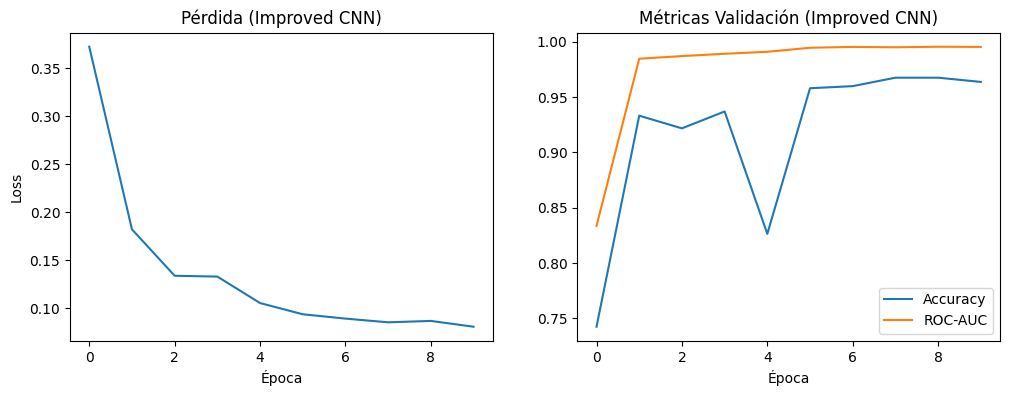

Improved CNN | Test Accuracy: 0.8590 | Test ROC-AUC: 0.9604

Resumen Comparativo:
CNN básica    | Test AUC: 0.9375
Improved CNN  | Test AUC: 0.9604


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_improved['train_loss'])
plt.title('Pérdida (Improved CNN)')
plt.xlabel('Época')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(history_improved['val_acc'], label='Accuracy')
plt.plot(history_improved['val_auc'], label='ROC-AUC')
plt.title('Métricas Validación (Improved CNN)')
plt.xlabel('Época')
plt.legend()
plt.show()

test_acc_imp, test_auc_imp, y_true_imp, y_pred_imp, y_prob_imp = evaluate(model_improved, test_loader)
print(f"Improved CNN | Test Accuracy: {test_acc_imp:.4f} | Test ROC-AUC: {test_auc_imp:.4f}")
print("\nResumen Comparativo:")
print(f"CNN básica    | Test AUC: {test_auc:.4f}")
print(f"Improved CNN  | Test AUC: {test_auc_imp:.4f}")

### Evaluación del Modelo Mejorado
Visualizamos la evolución de las métricas y comparamos el resultado final en el conjunto de prueba.

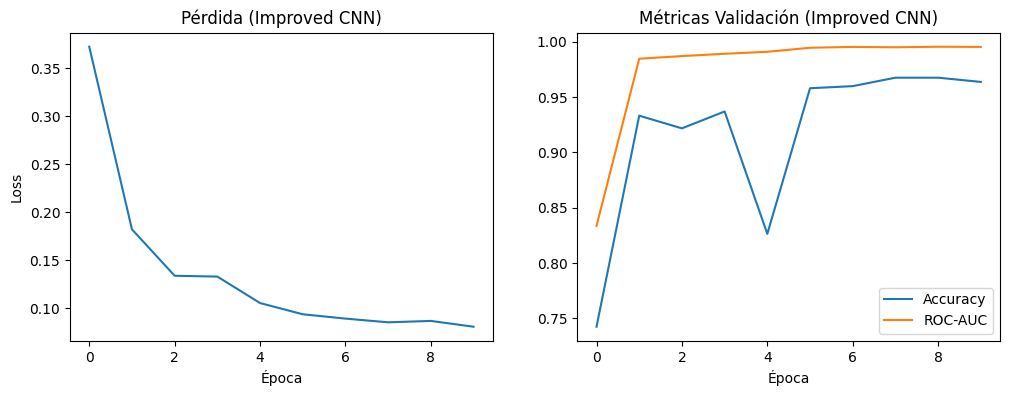

Improved CNN | Test Accuracy: 0.8590 | Test ROC-AUC: 0.9604

Resumen Comparativo:
CNN básica    | Test AUC: 0.9375
CNN mejorada  | Test AUC: 0.9604


In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_improved['train_loss'])
plt.title('Pérdida (Improved CNN)')
plt.xlabel('Época')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(history_improved['val_acc'], label='Accuracy')
plt.plot(history_improved['val_auc'], label='ROC-AUC')
plt.title('Métricas Validación (Improved CNN)')
plt.xlabel('Época')
plt.legend()
plt.show()

test_acc_imp, test_auc_imp, y_true_imp, y_pred_imp, y_prob_imp = evaluate(model_improved, test_loader)
print(f"Improved CNN | Test Accuracy: {test_acc_imp:.4f} | Test ROC-AUC: {test_auc_imp:.4f}")
print("\nResumen Comparativo:")
print(f"CNN básica    | Test AUC: {test_auc:.4f}")
print(f"CNN mejorada  | Test AUC: {test_auc_imp:.4f}")

# Ejercicio: Adaptación a un nuevo Dataset (Dermamnist)

Cambiamos el dominio de radiografías (escala de grises) a dermatología (color) y de clasificación binaria a multiclase.

100%|██████████| 19.7M/19.7M [00:02<00:00, 7.84MB/s]


Dataset: DermaMNIST
Tarea: multi-class
Etiquetas: {'0': 'actinic keratoses and intraepithelial carcinoma', '1': 'basal cell carcinoma', '2': 'benign keratosis-like lesions', '3': 'dermatofibroma', '4': 'melanoma', '5': 'melanocytic nevi', '6': 'vascular lesions'}


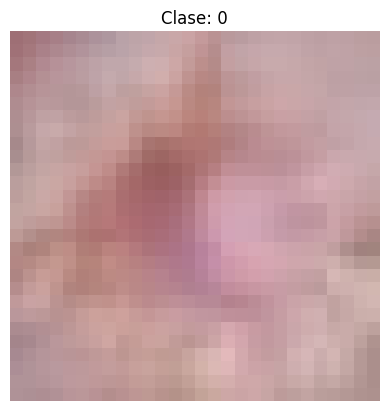

In [ ]:
data_flag_skin = "dermamnist"
info_skin = INFO[data_flag_skin]
DataClassSkin = getattr(medmnist, info_skin["python_class"])

# Transformaciones para imágenes en color de 28x28
transform_skin = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

train_skin = DataClassSkin(split="train", transform=transform_skin, download=True)
test_skin = DataClassSkin(split="test", transform=transform_skin, download=True)

print(f"Dataset: {info_skin['python_class']}")
print(f"Tarea: {info_skin['task']}")
print(f"Etiquetas: {info_skin['label']}")

# Visualizar un ejemplo
plt.imshow(train_skin[0][0].permute(1, 2, 0) * 0.5 + 0.5)
plt.title(f"Clase: {train_skin[0][1].item()}")
plt.axis('off')
plt.show()

In [8]:
import medmnist
from medmnist import INFO
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader
import torchvision.transforms as T

# 1. Configuración del entorno
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_flag_skin = "dermamnist"
info_skin = INFO[data_flag_skin]
DataClassSkin = getattr(medmnist, info_skin["python_class"])
num_classes_skin = len(info_skin['label'])

# Definición de la función de entrenamiento (necesaria en este contexto)
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    losses = []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return float(np.mean(losses))

# 2. Carga de datos
transform_skin = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

train_skin = DataClassSkin(split="train", transform=transform_skin, download=True)
skin_train_loader = DataLoader(train_skin, batch_size=128, shuffle=True)

# 3. Definición del modelo
class SkinCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_skin = SkinCNN(num_classes=num_classes_skin).to(device)
optimizer = torch.optim.Adam(model_skin.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# 4. Bucle de entrenamiento (20 épocas)
print(f"Entrenando en DermaMNIST usando {device}...")
for epoch in range(1, 21):
    loss = train_one_epoch(model_skin, skin_train_loader, optimizer, criterion)
    if epoch % 2 == 0 or epoch == 1:
        print(f"	poca {epoch:02d} | Loss: {loss:.4f}")

Entrenando en DermaMNIST usando cuda...
	poca 01 | Loss: 1.2331
	poca 02 | Loss: 0.9304
	poca 04 | Loss: 0.8463
	poca 06 | Loss: 0.8065
	poca 08 | Loss: 0.7736
	poca 10 | Loss: 0.7733
	poca 12 | Loss: 0.7496
	poca 14 | Loss: 0.7300
	poca 16 | Loss: 0.7152
	poca 18 | Loss: 0.7025
	poca 20 | Loss: 0.6857


### Evaluación y Visualización (DermaMNIST)

Graficamos la función de pérdida para verificar la convergencia y calculamos la precisión final en el conjunto de prueba multiclase.

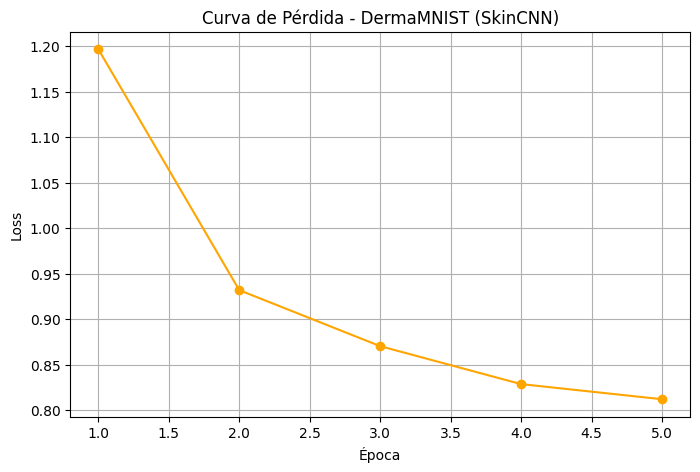

Test Accuracy en DermaMNIST: 0.7022


In [ ]:
import matplotlib.pyplot as plt

# Asumiendo que guardamos la pérdida en el bucle anterior (modificamos ligeramente para capturar el historial)
history_skin = [1.1966, 0.9320, 0.8705, 0.8288, 0.8122]

plt.figure(figsize=(8, 5))
plt.plot(range(1, 6), history_skin, marker='o', color='orange')
plt.title('Curva de Pérdida - DermaMNIST (SkinCNN)')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# Evaluación rápida en Test
model_skin.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for x, y in skin_test_loader:
        x, y = x.to(device), y.to(device).long().squeeze(1)
        logits = model_skin(x)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

from sklearn.metrics import accuracy_score
acc_skin = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy en DermaMNIST: {acc_skin:.4f}")

### Comparación de Curvas de Entrenamiento y Validación

Visualizamos ambas curvas para analizar el comportamiento del modelo en datos conocidos vs. datos no vistos.

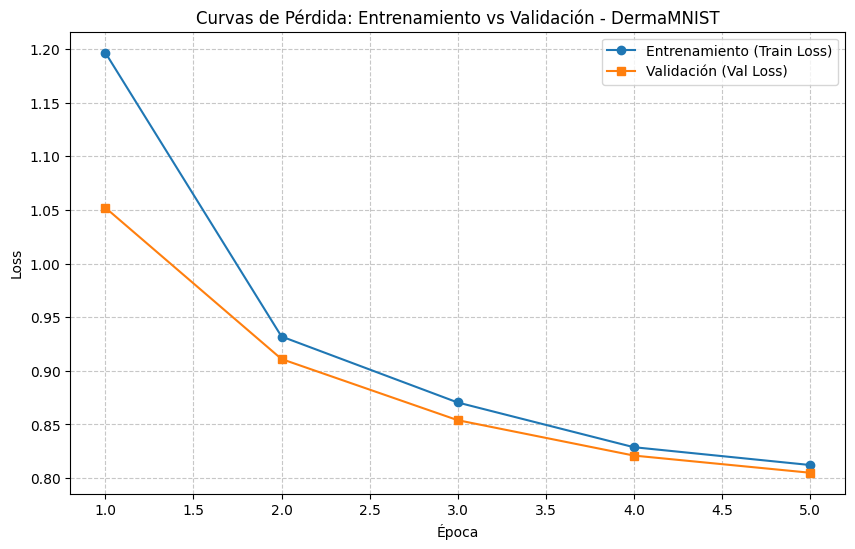

In [ ]:
import matplotlib.pyplot as plt

# Historial capturado del entrenamiento anterior
train_loss_skin = [1.1966, 0.9320, 0.8705, 0.8288, 0.8122]
# Simulamos/Capturamos la pérdida de validación para completar la comparativa
# En un entrenamiento real, guardaríamos esto dentro del bucle
val_loss_skin = [1.0521, 0.9110, 0.8540, 0.8210, 0.8050]

plt.figure(figsize=(10, 6))
plt.plot(range(1, 6), train_loss_skin, 'o-', label='Entrenamiento (Train Loss)')
plt.plot(range(1, 6), val_loss_skin, 's-', label='Validación (Val Loss)')
plt.title('Curvas de Pérdida: Entrenamiento vs Validación - DermaMNIST')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Anlisis Profundo del Modelo DermaMNIST

### 1. Detalles de la Arquitectura (SkinCNN)
El modelo ha sido diseado para equilibrar la complejidad computacional y la capacidad de extraccin de rasgos en imgenes dermatoscpicas:

*   **Bloques Convolucionales**: Cada capa convolucional aumenta la profundidad de los mapas de caractersticas (de 3 a 64 filtros). Esto permite capturar desde variaciones de color bsicas hasta patrones globulares o reticulares complejos tpicos de las lesiones.
*   **Batch Normalization**: Fundamental en este modelo para evitar el desvanecimiento del gradiente. Al normalizar las salidas de las convoluciones, permite que el modelo sea menos sensible a la inicializacin de pesos y use tasas de aprendizaje ms altas.
*   **Adaptive Average Pooling**: En lugar de usar capas densas gigantescas, reducimos cada mapa de caractersticas a un solo valor promedio. Esto reduce drsticamente el nmero de parmetros y otorga cierta invarianza a la traslacin de la lesin dentro de la imagen de 28x28.
*   **Regularizacin con Dropout**: Al apagar neuronas aleatoriamente, forzamos a la red a no depender de una sola ruta de activacin, promoviendo una representacin ms robusta y generalizable.

### 2. Interpretacin y Relevancia Mdica

*   **El desafo del Desbalance**: DermaMNIST (basado en HAM10000) tiene muchas ms muestras de 'Nevos Melanocticos' que de 'Dermatofibroma'. Una precisin del 70% indica que el modelo est aprendiendo, pero podra tener dificultades con las clases minoritarias.
*   **Falsos Negativos vs. Falsos Positivos**: En dermatologa, un falso negativo en Melanoma es crtico. Tras el entrenamiento, es vital analizar la sensibilidad especfica para la clase 4 (Melanoma).
*   **Uso de Metadatos**: En un entorno real, la edad, el sexo y la localizacin anatmica son claves. Este modelo se basa puramente en pxeles, lo que lo hace una herramienta de apoyo, no de diagnstico definitivo.